<h1 align = 'center'><span style = 'color:#0ca979'>🩺 Healthcare Analysis 🧪</span></h1>

<h>we conduct an exploratory data analysis (EDA) using a comprehensive dataset containing 10,000 records of patient admissions. The dataset includes information such as patient demographics, medical conditions, hospital operations, financial details, and more. Our objective is to extract meaningful insights from this data to inform decision-making processes within the healthcare organization.<br>
The report is structured as follows: we begin with an overview of the dataset, describing the variables and their distributions. We then delve into exploratory analyses across various dimensions, including patient demographics, medical conditions, hospital operations, and financial aspects. Following the exploratory phase, we transition to predictive modeling, aiming to forecast patient outcomes and financial metrics based on available data.
</h>


<h2>Importing Libraries</h2>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import AgglomerativeClustering

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

<h2>Reading dataset</h2>

In [2]:
df = pd.read_csv('/kaggle/input/healthcare-dataset/healthcare_dataset.csv')

<h2>Exploring Data </h2>


In [3]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

In [4]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


<h2>Data Cleaning</h2>

<h3>Checking for null values and data types</h3>

In [5]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])

In [6]:
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Age                 10000 non-null  int64         
 2   Gender              10000 non-null  object        
 3   Blood Type          10000 non-null  object        
 4   Medical Condition   10000 non-null  object        
 5   Date of Admission   10000 non-null  datetime64[ns]
 6   Doctor              10000 non-null  object        
 7   Hospital            10000 non-null  object        
 8   Insurance Provider  10000 non-null  object        
 9   Billing Amount      10000 non-null  float64       
 10  Room Number         10000 non-null  int64         
 11  Admission Type      10000 non-null  object        
 12  Discharge Date      10000 non-null  datetime64[ns]
 13  Medication          10000 non-null  object     

<h3>Checking duplicated rows</h3>

In [8]:
duplicated = df[df.duplicated()]
duplicated

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


<h3>Checking Outliers</h3>

In [9]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,10000.000000,10000,10000.000000,10000.000000,10000
mean,51.452200,2021-05-01 21:53:25.439999744,25516.806778,300.082000,2021-05-17 11:22:24.960000
min,18.000000,2018-10-30 00:00:00,1000.180837,101.000000,2018-11-01 00:00:00
25%,35.000000,2020-02-10 00:00:00,13506.523967,199.000000,2020-02-23 18:00:00
50%,52.000000,2021-05-02 00:00:00,25258.112566,299.000000,2021-05-18 00:00:00
75%,68.000000,2022-07-23 06:00:00,37733.913727,400.000000,2022-08-07 00:00:00
max,85.000000,2023-10-30 00:00:00,49995.902283,500.000000,2023-11-27 00:00:00
std,19.588974,NaN,14067.292709,115.806027,NaN


In [10]:
#Defining function to check Outliers using Z-Scores.
def outliers(column_name,tune = 3):
    mean_column = df[column_name].mean()
    std_column = df[column_name].std()
    threshold = mean_column+tune*std_column
    outlier = df[df[column_name] > threshold]
    if outlier.empty:
        print("There are no outliers. ")
    else:
        return outlier
    

In [11]:
outliers('Age',tune = 2)

There are no outliers. 


In [12]:
#Checking if discharge date in earlier than admission date.
miss_match_dates = df['Discharge Date'] < df['Date of Admission']

In [13]:
df_miss = df[miss_match_dates]

In [14]:
df_miss

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


In [15]:
miss_match_dates_count = (df['Discharge Date'] < df['Date of Admission']).sum()
print(miss_match_dates_count)

0


/opt/conda/lib/python3.10/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age'>

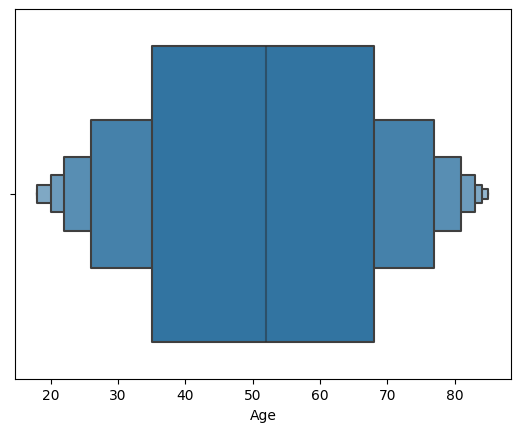

In [16]:
#visualizing outliers using Boxplot.
sns.boxenplot(x = 'Age', data = df)

<h2>Exploratory Analysis</h2>

<h3>Descriptive Analysis</h3>

<h4>What is the distribution of ages in the dataset?</h4>

In [17]:
#Ascessing Age column.
age = df['Age']

In [18]:
#Calculating summary statstics.
age.describe()

count    10000.000000
mean        51.452200
std         19.588974
min         18.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         85.000000
Name: Age, dtype: float64

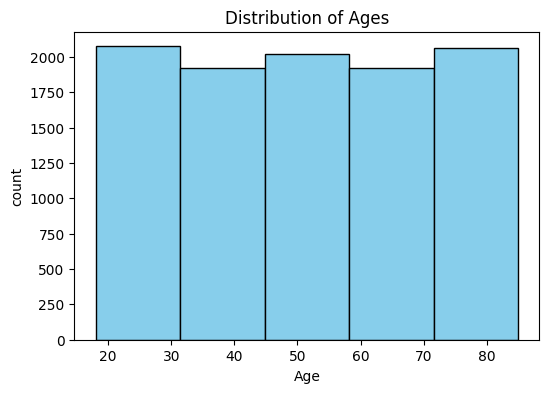

In [19]:
#Visualizing the distribution of ages using histogram.
plt.figure(figsize = (6,4))
plt.hist(age, bins=5, color='skyblue', edgecolor = 'black')
plt.title("Distribution of Ages")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

<h4>What are the 10 most common medical conditions among patients?</h4>

In [20]:
count_medical_conditions = (df['Medical Condition']).value_counts()

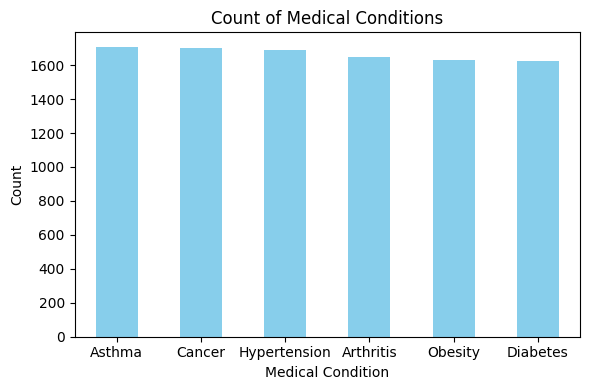

In [21]:
plt.figure(figsize=(6, 4))
count_medical_conditions.plot(kind='bar', color='skyblue')
plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Count of Medical Conditions')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

<h4>How many unique doctors and hospitals are represented in the dataset?</h4>

In [22]:
unique_doctor_count = df['Doctor'].nunique()
unique_hospital_count = df['Hospital'].nunique()
print(f"unique Doctor: {unique_doctor_count}")
print(f"unique Hospital: {unique_hospital_count}")

unique Doctor: 9416
unique Hospital: 8639


<h4>What are the most common blood types?</h4>

In [23]:
common_blood_type = (df['Blood Type']).value_counts().sort_values(ascending=False)
common_blood_type

Blood Type
AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: count, dtype: int64

<h4>What is the average billing amount for admissions?</h4>


In [24]:
df['Billing Amount'].mean()

25516.8067777384

<h4>How many different insurance providers are there and what is their distribution?</h4>

In [25]:
insurance_distribution_name = (df['Insurance Provider']).value_counts()
insurance_distribution_name

Insurance Provider
Cigna               2040
Blue Cross          2032
Aetna               2025
UnitedHealthcare    1978
Medicare            1925
Name: count, dtype: int64

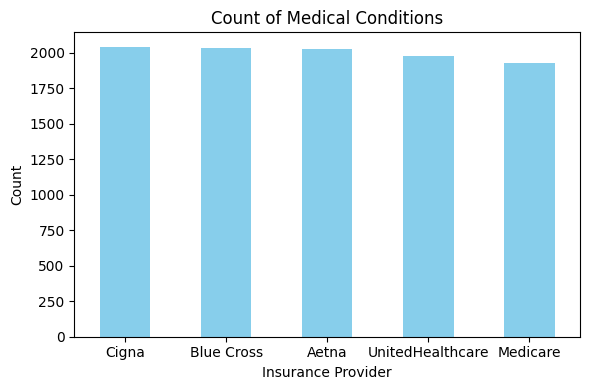

In [26]:
plt.figure(figsize=(6, 4))
insurance_distribution_name.plot(kind='bar', color='skyblue')
plt.xlabel('Insurance Provider')
plt.ylabel('Count')
plt.title('Count of Medical Conditions')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

<h3>Patient Demographics</h3>

<h4>What is the gender distribution of patients?</h4>


In [27]:
gender_count = df['Gender'].value_counts()
gender_count

Gender
Female    5075
Male      4925
Name: count, dtype: int64

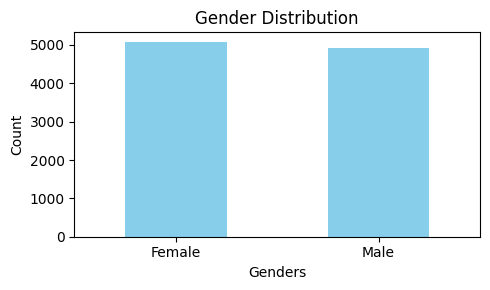

In [28]:
plt.figure(figsize=(5, 3))
gender_count.plot(kind='bar', color='skyblue')
plt.xlabel('Genders')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

<h4>Are there any correlations between age and medical conditions?</h4>

In [29]:
# Perform one-hot encoding for the 'Medical Condition' column
medical_conditions_encoded = pd.get_dummies(df['Medical Condition'])

# Concatenate the one-hot encoded columns with the original DataFrame
df_encoded = pd.concat([df, medical_conditions_encoded], axis=1)

# Calculate the correlation between 'Age' and each medical condition
correlation_with_age = df_encoded[['Age', 'Asthma', 'Cancer', 'Hypertension', 'Arthritis', 'Obesity', 'Diabetes']].corr()

# Extract the correlation between 'Age' and each medical condition
correlation_with_age = correlation_with_age['Age'][1:]

# Print the correlation coefficients
print("Correlation between Age and each medical condition:")
print(correlation_with_age)

Correlation between Age and each medical condition:
Asthma         -0.000154
Cancer          0.003041
Hypertension   -0.016441
Arthritis       0.001786
Obesity         0.004091
Diabetes        0.007865
Name: Age, dtype: float64


<h4>Are there any patterns in admission types based on patient demographics?</h4>

In [30]:
# Create cross-tabulation between 'Admission Type' and 'Gender'
admission_gender_cross = pd.crosstab(index=df['Admission Type'], columns=df['Gender'])

# Create cross-tabulation between 'Admission Type' and 'Age Group'
# You need to define age groups first, for example:
bins = [0, 18, 30, 50, 70, 100]  # Define age group bins
labels = ['0-17', '18-29', '30-49', '50-69', '70+']  # Define labels for age groups
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)  # Create 'Age Group' column
admission_age_cross = pd.crosstab(index=df['Admission Type'], columns=df['Age Group'])

# Print cross-tabulation results
print("Cross-tabulation between Admission Type and Gender:")
print(admission_gender_cross)
print("\nCross-tabulation between Admission Type and Age Group:")
print(admission_age_cross)

Cross-tabulation between Admission Type and Gender:
Gender          Female  Male
Admission Type              
Elective          1640  1602
Emergency         1701  1666
Urgent            1734  1657

Cross-tabulation between Admission Type and Age Group:
Age Group       0-17  18-29  30-49  50-69  70+
Admission Type                                
Elective          52    573    934    985  698
Emergency         63    577    974   1000  753
Urgent            49    589    985   1006  762


<h4>How does the distribution of medical conditions vary by gender?</h4>

In [31]:
# Create cross-tabulation between 'Medical Condition' and 'Gender'
medical_condition_gender_cross = pd.crosstab(index=df['Medical Condition'], columns=df['Gender'])

# Print cross-tabulation results
print("Cross-tabulation between Medical Condition and Gender:")
print(medical_condition_gender_cross)

Cross-tabulation between Medical Condition and Gender:
Gender             Female  Male
Medical Condition              
Arthritis             815   835
Asthma                874   834
Cancer                887   816
Diabetes              825   798
Hypertension          836   852
Obesity               838   790


<h4>Is there a correlation between age and the length of hospital stay?</h4>

In [32]:
# Calculate the length of stay in days
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Calculate the Pearson correlation coefficient
correlation = df['Age'].corr(df['Length of Stay'])

# Print the correlation coefficient
print("Pearson correlation coefficient between Age and Length of Stay:", correlation)

Pearson correlation coefficient between Age and Length of Stay: 0.009111433218769093


<h3>Medical Insights</h3

<h4>What are the top 10 most common medical conditions in the dataset?</h4>

In [33]:
most_common_medical_condition = df['Medical Condition'].value_counts()
most_common_medical_condition

Medical Condition
Asthma          1708
Cancer          1703
Hypertension    1688
Arthritis       1650
Obesity         1628
Diabetes        1623
Name: count, dtype: int64

<h4>Are certain medical conditions more prevalent in specific age groups?</h4>

In [34]:
# Define age group bins and labels
bins = [18, 30, 50, 70, 100]  # Define age group bins
labels = ['18-29', '30-49', '50-69', '70+']  # Define labels for age groups
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)  # Create 'Age Group' column

# Create cross-tabulation between 'Medical Condition' and 'Age Group' with normalization
medical_condition_age_cross = pd.crosstab(index=df['Medical Condition'], columns=df['Age Group'], normalize='index')

# Print cross-tabulation results (as percentage)
print("Percentage of each medical condition within different age groups:")
print(medical_condition_age_cross * 100)

Percentage of each medical condition within different age groups:
Age Group              18-29      30-49      50-69        70+
Medical Condition                                            
Arthritis          16.769420  30.332922  30.456227  22.441430
Asthma             17.608566  29.684711  30.696014  22.010708
Cancer             17.253731  29.313433  30.388060  23.044776
Diabetes           17.459324  28.535670  30.788486  23.216521
Hypertension       18.791541  30.271903  28.882175  22.054381
Obesity            18.193146  28.286604  31.277259  22.242991


<h4>Can we identify any clusters of medical conditions that often occur together?</h4>

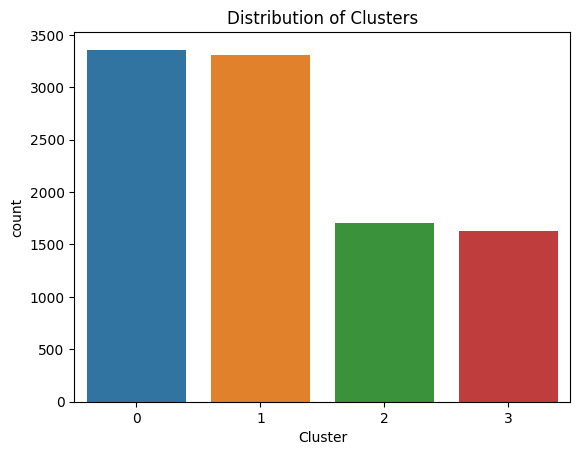

Cluster 0: ['Asthma' 'Arthritis']
Cluster 1: ['Diabetes' 'Hypertension']
Cluster 2: ['Cancer']
Cluster 3: ['Obesity']


In [35]:
medical_conditions = df['Medical Condition']

# Encode medical conditions to numerical values
label_encoder = LabelEncoder()
medical_conditions_encoded = label_encoder.fit_transform(medical_conditions)

# Apply hierarchical clustering
cluster = AgglomerativeClustering(n_clusters=None, distance_threshold=50)
cluster_labels = cluster.fit_predict(medical_conditions_encoded.reshape(-1, 1))

# Add cluster labels back to DataFrame
df['Cluster'] = cluster_labels

# Visualize the clusters
sns.countplot(x='Cluster', data=df)
plt.title('Distribution of Clusters')
plt.show()

# Print the clusters and their associated medical conditions
clustered_conditions = df.groupby('Cluster')['Medical Condition'].unique()
for cluster, conditions in clustered_conditions.items():
    print(f'Cluster {cluster}: {conditions}')
